In [145]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import pandas as pd
import os
import math

#Pending 006 , 007, 008
image_path = r'Clenead_Images\XY_clean\xy006.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
scene_coordinate_system = -16.41414 #Variable depending of the image

#Scale the values based of the scale
height_pixels, width_pixels = image.shape[:2]
scale_mm = 4.5 / 208  #mm x pixel
with_mm = width_pixels * scale_mm #
high_mm = height_pixels * scale_mm



print(f"Dimensiones de la imagen: {width_pixels}x{height_pixels} píxeles")
print(f"Escala: {scale_mm:.6f} mm/px")
print(f"Dimensiones de la imagen en milímetros: {with_mm:.2f}mm x {high_mm:.2f}mm")



Dimensiones de la imagen: 1467x933 píxeles
Escala: 0.021635 mm/px
Dimensiones de la imagen en milímetros: 31.74mm x 20.19mm


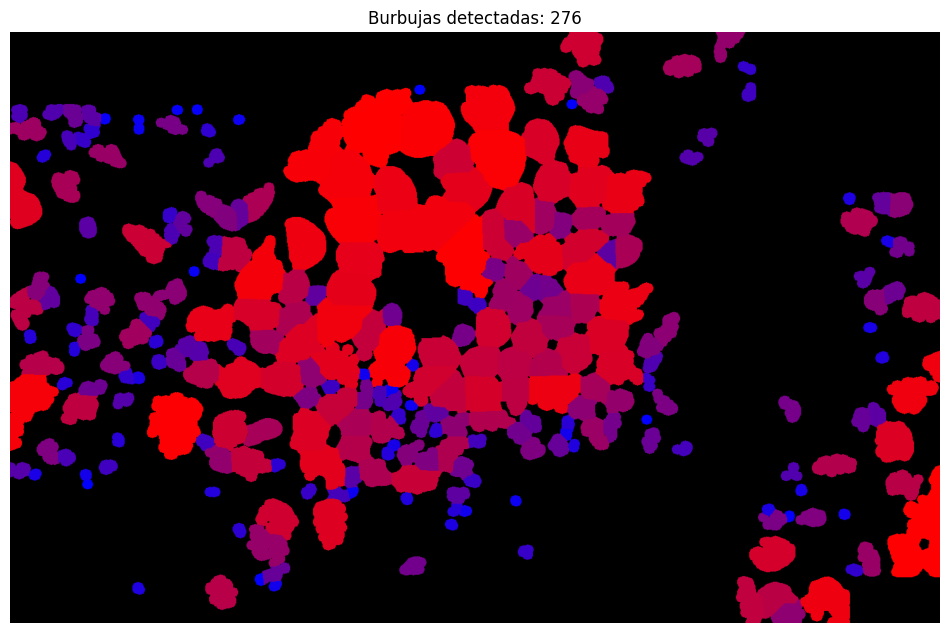

In [154]:
# Definir umbrales
max_area_threshold = 10000 #10000
min_area_threshold = 0    # Umbral

# 1. Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(image, (5, 5), 0) #23,23,(<008) 5,5(blackers-009)

# 2. Binarizar usando umbral de Otsu
_, binary = cv2.threshold(blur, 80, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary = cv2.bitwise_not(binary)

# 3. Operaciones morfológicas para limpiar pequeñas manchas y separar un poco las burbujas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9)) # 15 15, 3,3(blackers - 009)
binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 4.Transformada de distancia
dist_transform = cv2.distanceTransform(binary_opened, cv2.DIST_L2, 5)

# 5. Encontrar los picos locales en la transformada de distancia
coordinates = peak_local_max(dist_transform, min_distance=10,threshold_abs=0.5) # 27 
local_max = np.zeros(dist_transform.shape, dtype=bool)
local_max[tuple(coordinates.T)] = True




# Etiquetar los picos para usarlos como marcadores en watershed
markers, _ = ndimage.label(local_max)

# 6.  la transformada de distancia negativa (para encontrar valles)
labels = watershed(-dist_transform, markers, mask=binary_opened)

# 7.Resultado
num_labels = labels.max()
areas = []
valid_count = 0


for lbl in range(1, num_labels+1):
    mask = (labels == lbl).astype(np.uint8)
    area = cv2.countNonZero(mask)
    
    
    # Filtrar por área 
    if min_area_threshold <= area <= max_area_threshold:
        areas.append((lbl,area))
        valid_count += 1
areas = sorted(areas,key=lambda x: x[1])
gradient_colors = np.linspace(0,255,len(areas),dtype=np.uint8)
colored_result = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

for i, (lbl, area) in enumerate(areas):
    # Asignar un color basado en el índice del gradiente
    color = (255 - gradient_colors[i], 0, gradient_colors[i])  # Azul -> Rojo
    colored_result[labels == lbl] = color

    


plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
plt.title(f"Burbujas detectadas: {valid_count}")
plt.axis('off')
plt.show()
#Por tamaño, patrones colores : READY
#Porcentaje de vacio, ocupado : READY 
#Modificar/Obtimizar segmentacion de las burbujas agrupadas

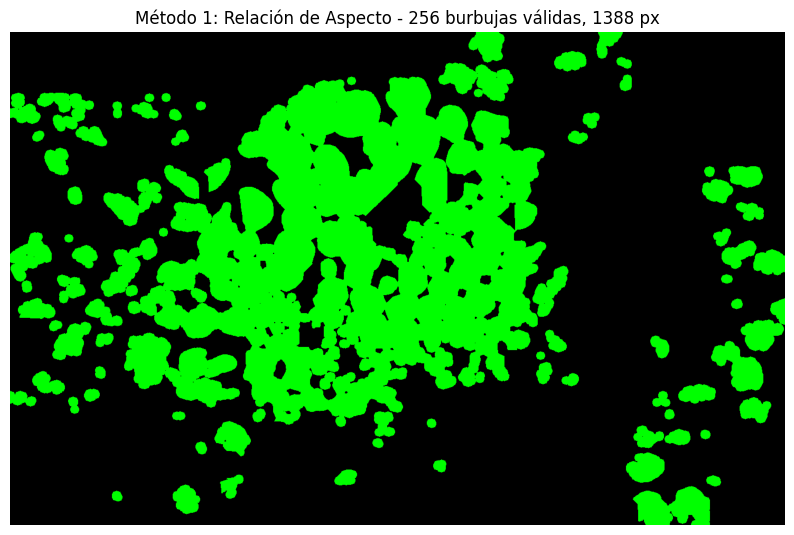

In [147]:
# Método 1: Relación de Aspecto
valid_count_aspect_ratio = 0
colored_result_aspect_ratio = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

for lbl in range(1, num_labels + 1):
    mask = (labels == lbl).astype(np.uint8)
    area_px = cv2.countNonZero(mask)
    x, y, w, h = cv2.boundingRect(mask)
    aspect_ratio = w / h if h > 0 else 0

    # Filtrar por relación de aspecto
    if 0.7 <= aspect_ratio:  # Rango para formas casi circulares
        valid_count_aspect_ratio += 1
        color = (0, 255, 0)  # Verde para las burbujas válidas
        colored_result_aspect_ratio[labels == lbl] = color

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(colored_result_aspect_ratio, cv2.COLOR_BGR2RGB))
plt.title(f"Método 1: Relación de Aspecto - {valid_count_aspect_ratio} burbujas válidas, {area_px} px")
plt.axis('off')
plt.show()



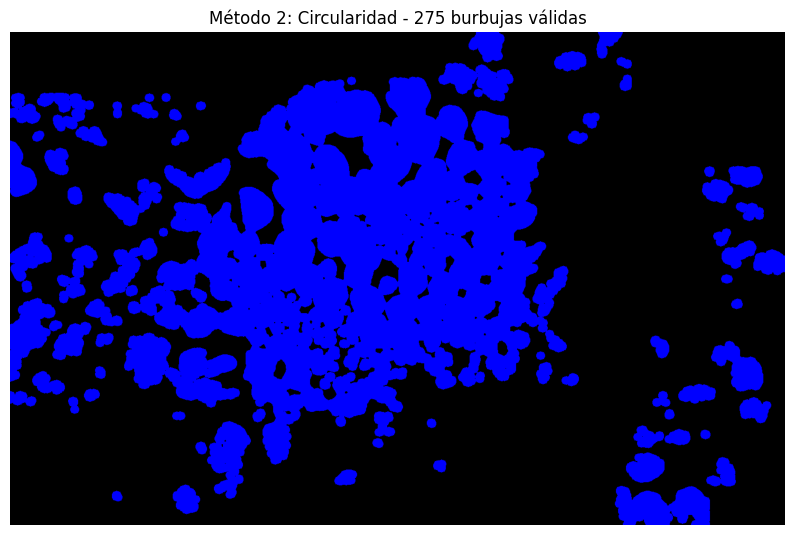

In [148]:
# Método 2: Circularidad
valid_count_circularity = 0
colored_result_circularity = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

for lbl in range(1, num_labels + 1):
    mask = (labels == lbl).astype(np.uint8)
    area = cv2.countNonZero(mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        perimeter_px = cv2.arcLength(contours[0], True)
    else:
        perimeter_px = 0.0

    # Calcular circularidad
    if perimeter_px > 0:
        circularity = (4 * math.pi * area) / (perimeter_px**2)
    else:
        circularity = 0

    # Filtrar por circularidad
    if circularity >= 0.4:  # Rango para formas razonablemente circulares
        valid_count_circularity += 1
        color = (255, 0, 0)  # Rojo para las burbujas válidas
        colored_result_circularity[labels == lbl] = color

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(colored_result_circularity, cv2.COLOR_BGR2RGB))
plt.title(f"Método 2: Circularidad - {valid_count_circularity} burbujas válidas")
plt.axis('off')
plt.show()




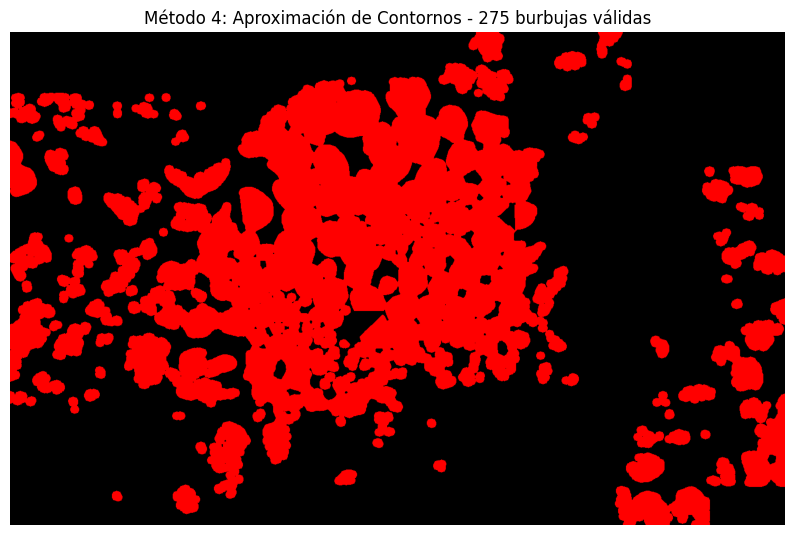

In [149]:
# Método 4: Aproximación de Contornos
valid_count_contours = 0
colored_result_contours = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

for lbl in range(1, num_labels + 1):
    mask = (labels == lbl).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        perimeter_px = cv2.arcLength(contours[0], True)
        epsilon = 0.02 * perimeter_px
        approx = cv2.approxPolyDP(contours[0], epsilon, True)

        # Filtrar formas cuadradas/rectangulares
        if len(approx) != 4:  # Si no es un cuadrado/rectángulo
            valid_count_contours += 1
            color = (0, 0, 255)  # Azul para las burbujas válidas
            colored_result_contours[labels == lbl] = color

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(colored_result_contours, cv2.COLOR_BGR2RGB))
plt.title(f"Método 4: Aproximación de Contornos - {valid_count_contours} burbujas válidas")
plt.axis('off')
plt.show()


In [150]:
# Calcular total de píxeles en la imagen
total_pixels = binary_opened.size  # Total de píxeles en la imagen

# Contar píxeles pintados (foreground) usando la imagen binaria
painted_pixels = np.count_nonzero(binary_opened)

# Calcular píxeles no pintados (background)
unpainted_pixels = total_pixels - painted_pixels

# Calcular porcentaje de píxeles no pintados
unpainted_percentage = (unpainted_pixels / total_pixels) * 100

print(f"Porcentaje no pintado: {unpainted_percentage:.2f}%")
#[40%] minimo 61.75%maximo - No pintado, Ignorar igual < 18% -[21], Then 21% < Acceptable < 40% (Margen of 15.35 less due the noise)

Porcentaje no pintado: 65.34%


In [151]:
image_name = os.path.splitext(os.path.basename(image_path))[0]

unpainted_percentage_adjusted = max(0, unpainted_percentage - 15.35)  # Ajuste

result_data = []
valid_count = 0

for lbl in range(1, num_labels+1):
    mask = (labels == lbl).astype(np.uint8)
    area_px = cv2.countNonZero(mask)

    if not (min_area_threshold <= area_px <= max_area_threshold):
        # Si no cumple el filtro, omitir esta burbuja
        continue

    # Calcular el perímetro
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        perimeter_px = cv2.arcLength(contours[0], True)
    else:
        perimeter_px = 0.0

    # Conversiones a mm
    diametro_px = math.sqrt((4 * area_px) / math.pi)  # Diámetro circular aproximado
    area_mm2 = area_px * (scale_mm**2)           # Área en mm^2
    perimetro_mm = perimeter_px * scale_mm       # Perímetro en mm
    diametro_mm = diametro_px * scale_mm         # Diámetro en mm

    result_data.append({
        'Imagen': image_name,
        'Scene_coordinate_system': scene_coordinate_system,
        'Area_px': area_px,
        'Area_mm2': area_mm2,
        'Perimetro_px': perimeter_px,
        'Perimetro_mm': perimetro_mm,
        'Diametro_px': diametro_px,
        'Diametro_mm': diametro_mm,
        'Escala_mm_por_px': scale_mm,
        'Porcentaje_no_pintado': unpainted_percentage_adjusted  # Nuevo dato
    })
    valid_count += 1


In [152]:
import os

csv_filename = "Bubbles_Results_V2.csv"  # CSV global

df = pd.DataFrame(result_data)

if not os.path.exists(csv_filename):
    
    df.to_csv(csv_filename, index=False)
else:
    
    df.to_csv(csv_filename, mode='a', header=False, index=False)

